In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (12, 6)
})

In [20]:
df_clean = pd.read_csv("../../data/processed/parking_violations_clean.csv")
df_exploded = pd.read_csv("../../data/processed/parking_violations_exploded_with_clusters.csv")
cluster_summary = pd.read_csv("../../data/processed/cluster_summary_checkpoint.csv")

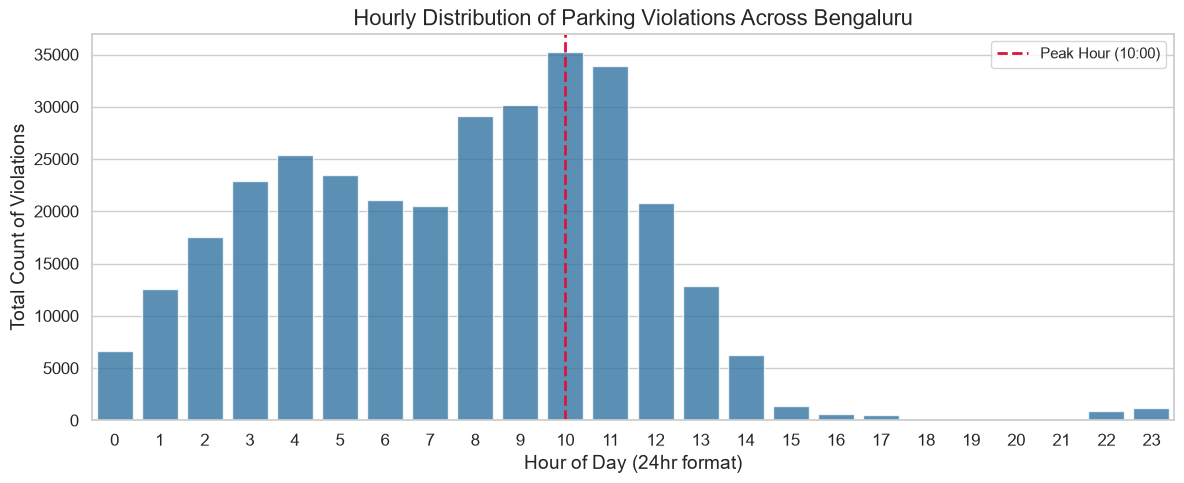

In [21]:
df_clusters = df_exploded[df_exploded['cluster_id'] != -1]

hourly_counts = df_clusters['cdt_hour'].value_counts().sort_index()
peak_hour = hourly_counts.idxmax()

plt.figure(figsize=(12, 5))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='#1f77b4', alpha=0.8)

plt.axvline(x=peak_hour, color='crimson', linestyle='--', linewidth=2,
            label=f'Peak Hour ({peak_hour:02d}:00)')

plt.title("Hourly Distribution of Parking Violations Across Bengaluru")
plt.xlabel("Hour of Day (24hr format)")
plt.ylabel("Total Count of Violations")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Anomoly due to Mass Dumping of Records during Late Night

In [22]:
distinct_per_ts = df_exploded.groupby('created_datetime')['id'].transform('nunique')
BURST_THRESHOLD = 15  

df_real_trends = df_exploded[distinct_per_ts < BURST_THRESHOLD].copy()

print(f"Removed {len(df_exploded) - len(df_real_trends)} rows "
      f"({(len(df_exploded) - len(df_real_trends)) / len(df_exploded) * 100:.2f}%) "
      f"as likely burst-dump artifacts")
print(f"Remaining: {len(df_real_trends)} rows")

Removed 6329 rows (1.96%) as likely burst-dump artifacts
Remaining: 317102 rows


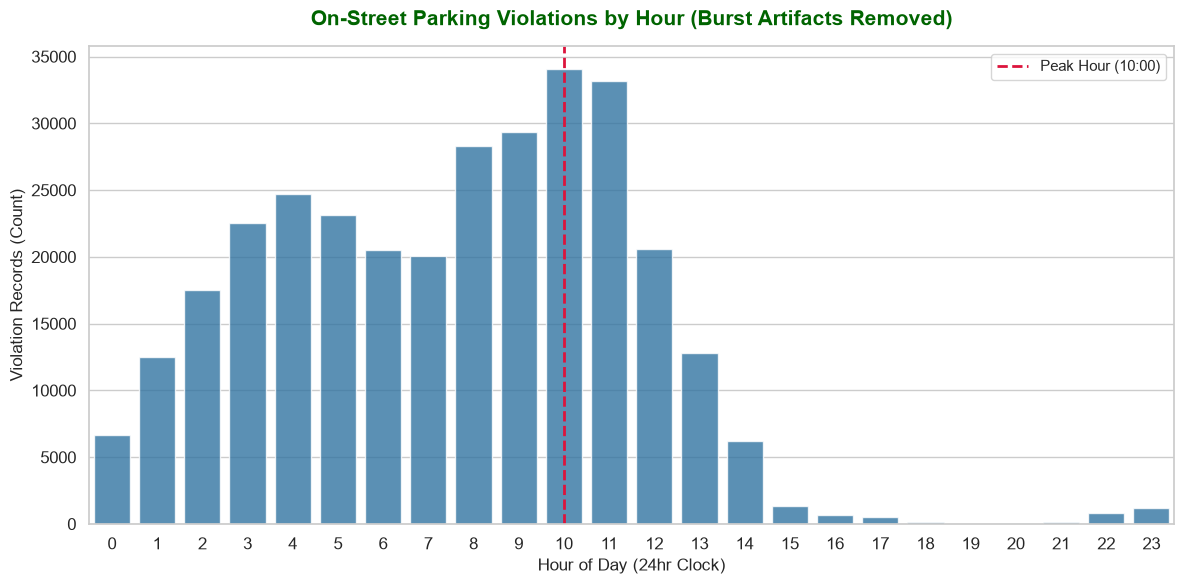

In [24]:
hourly_counts_clean = df_real_trends['cdt_hour'].value_counts().sort_index()
peak_hour_clean = hourly_counts_clean.idxmax()

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_counts_clean.index, y=hourly_counts_clean.values,
            color='#1f77b4', alpha=0.8)

plt.axvline(x=peak_hour_clean, color='crimson', linestyle='--', linewidth=2,
            label=f'Peak Hour ({peak_hour_clean:02d}:00)')

plt.title("On-Street Parking Violations by Hour (Burst Artifacts Removed)",
          fontsize=15, color='darkgreen', pad=15, weight='bold')
plt.xlabel("Hour of Day (24hr Clock)", fontsize=12)
plt.ylabel("Violation Records (Count)", fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

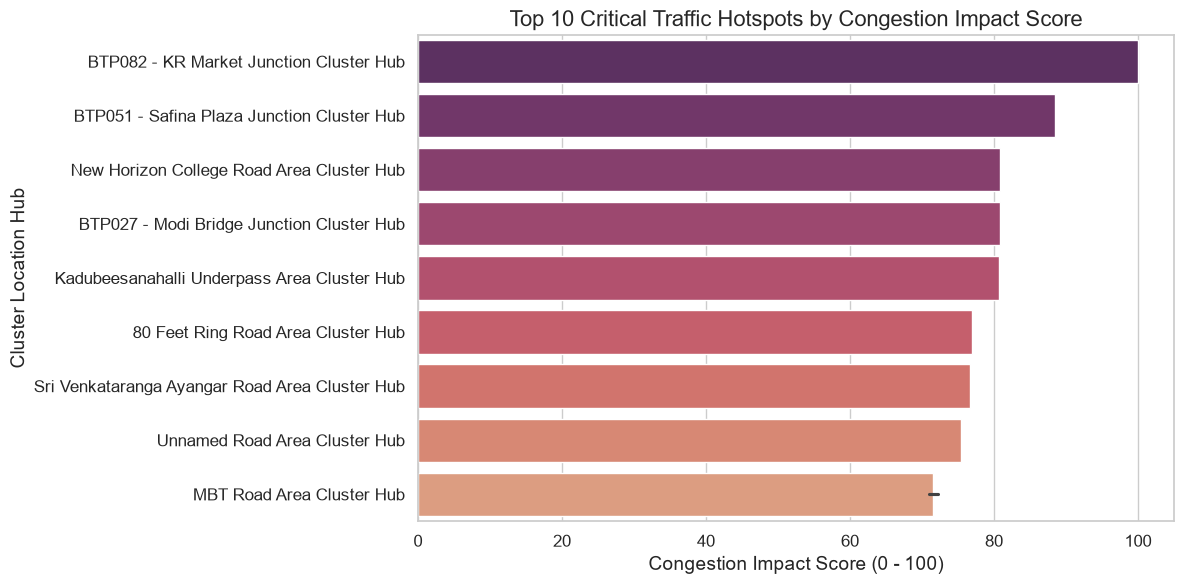

In [25]:
if 'cluster_summary' in locals() or 'cluster_summary' in globals():
    top_clusters = cluster_summary.sort_values(by='congestion_impact_score', ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=top_clusters, 
        y='cluster_name', 
        x='congestion_impact_score', 
        palette='flare_r',
        hue='cluster_name',
        legend=False
    )
    plt.title("Top 10 Critical Traffic Hotspots by Congestion Impact Score")
    plt.xlabel("Congestion Impact Score (0 - 100)")
    plt.ylabel("Cluster Location Hub")
    plt.tight_layout()
    plt.show()

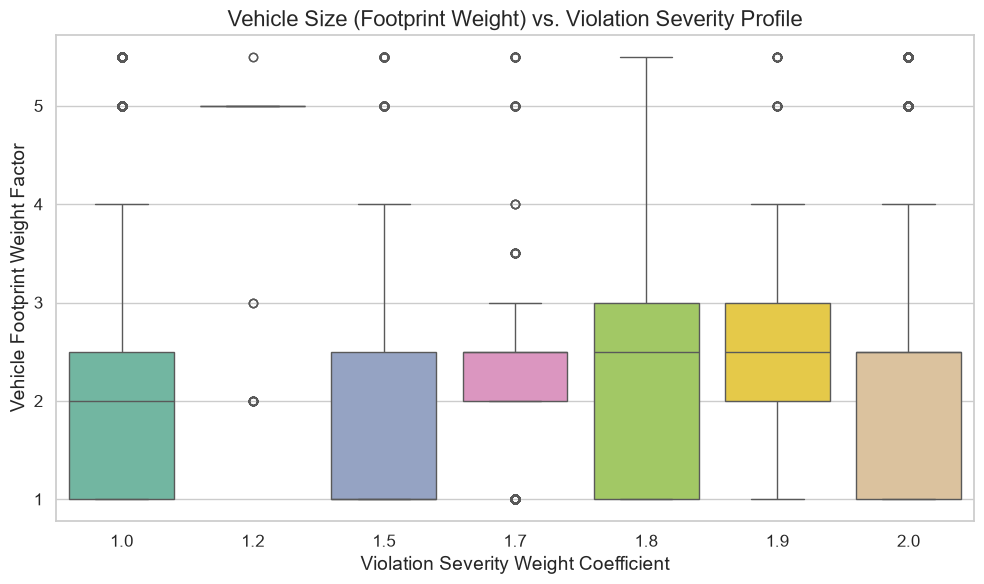

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clusters, 
    x='violation_severity_weight', 
    y='vehicle_footprint_weight', 
    palette='Set2',
    hue='violation_severity_weight',
    legend=False
)
plt.title("Vehicle Size (Footprint Weight) vs. Violation Severity Profile")
plt.xlabel("Violation Severity Weight Coefficient")
plt.ylabel("Vehicle Footprint Weight Factor")
plt.tight_layout()
plt.show()

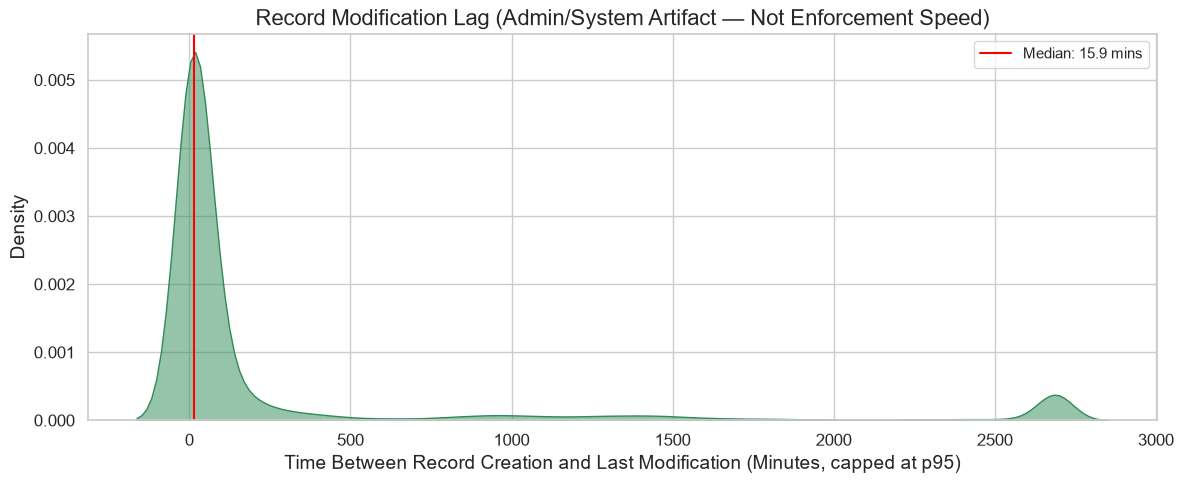

In [27]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df_clean, x='record_lifecycle_minutes_capped_p95',
            fill=True, color='seagreen', alpha=0.5)

median_val = df_clean['record_lifecycle_minutes_capped_p95'].median()
plt.axvline(x=median_val, color='red', linestyle='-',
            label=f"Median: {median_val:.1f} mins")

plt.title("Record Modification Lag (Admin/System Artifact — Not Enforcement Speed)")
plt.xlabel("Time Between Record Creation and Last Modification (Minutes, capped at p95)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

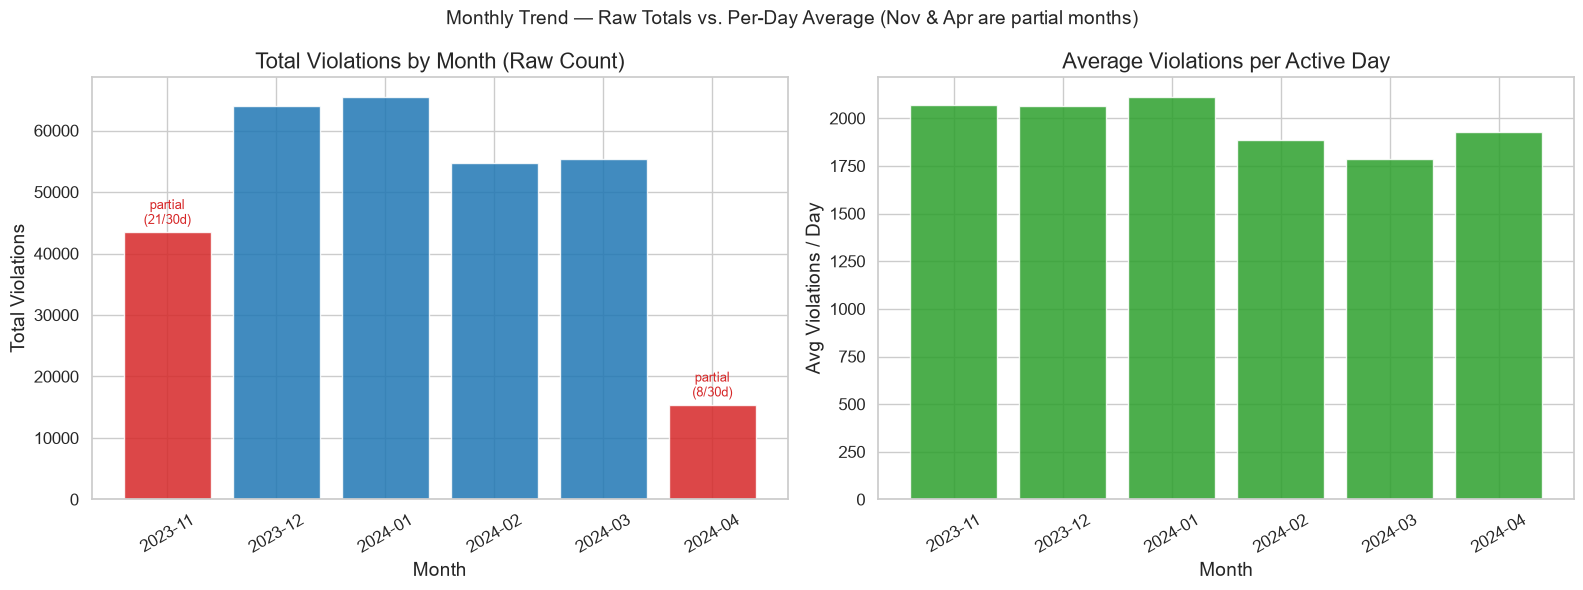

In [28]:
import calendar

df_clean['created_datetime'] = pd.to_datetime(df_clean['created_datetime'])
df_clean['month_period'] = df_clean['created_datetime'].dt.tz_localize(None).dt.to_period('M')

days_active = df_clean.groupby('month_period')['created_datetime'].apply(
    lambda s: s.dt.date.nunique()
)
monthly_counts = df_clean['month_period'].value_counts().sort_index()
avg_per_day = (monthly_counts / days_active).round(1)

calendar_days = pd.Series({
    p: calendar.monthrange(p.year, p.month)[1] for p in monthly_counts.index
})
is_partial = days_active < calendar_days
month_labels = [str(p) for p in monthly_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#d62728' if p else '#1f77b4' for p in is_partial]
axes[0].bar(month_labels, monthly_counts.values, color=colors, alpha=0.85)
axes[0].set_title("Total Violations by Month (Raw Count)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Violations")
axes[0].tick_params(axis='x', rotation=30)
for i in range(len(month_labels)):
    if is_partial.iloc[i]:
        axes[0].text(i, monthly_counts.values[i] + monthly_counts.max() * 0.02,
                     f"partial\n({days_active.iloc[i]}/{calendar_days.iloc[i]}d)",
                     ha='center', fontsize=9, color='#d62728')

axes[1].bar(month_labels, avg_per_day.values, color='#2ca02c', alpha=0.85)
axes[1].set_title("Average Violations per Active Day")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Violations / Day")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Monthly Trend — Raw Totals vs. Per-Day Average "
             "(Nov & Apr are partial months)", fontsize=14)
plt.tight_layout()
plt.show()